# Lists as custom class
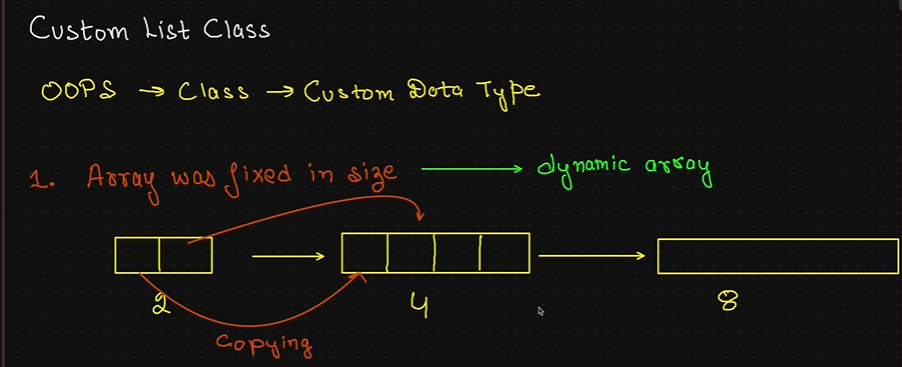
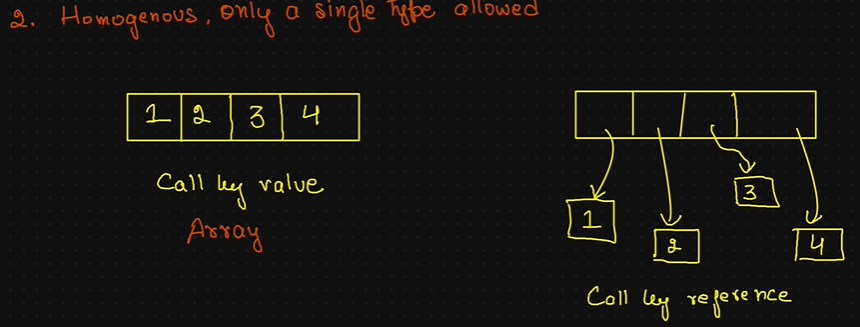

In [1]:
import sys
l1=[]
print(f"Initial size, {sys.getsizeof(l1)}")
for i in range(16):
    l1.append(i)
    print(f"{i} ---> {sys.getsizeof(l1)}")

Initial size, 56
0 ---> 88
1 ---> 88
2 ---> 88
3 ---> 88
4 ---> 120
5 ---> 120
6 ---> 120
7 ---> 120
8 ---> 184
9 ---> 184
10 ---> 184
11 ---> 184
12 ---> 184
13 ---> 184
14 ---> 184
15 ---> 184


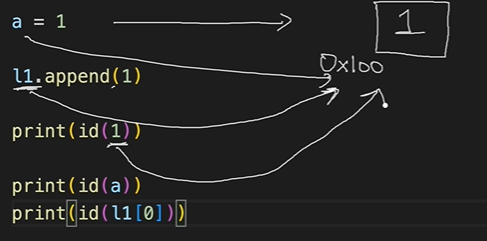

In [6]:
# id function.
# Returns the identity of an object.
# Guaranteed to be unique among simultaneously existing objects.
# Python uses object memory address.
a=1
l1.append(a)
print(id(a))
print(id(l1[0]))


1609329803504
1609329803472


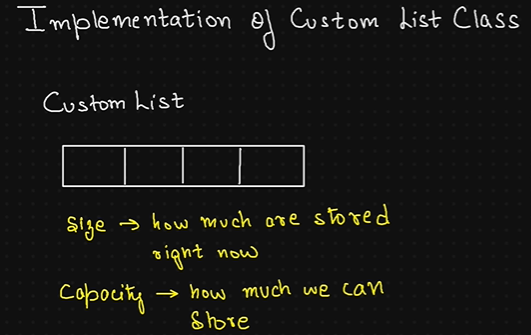

ctypes - ctypes is a built-in Python library that allows you to call C functions and use C data types directly from Python code without needing to compile Python extensions.
You can:
Load shared libraries (.dll, .so, .dylib)
Call their functions
Define and pass C-compatible data types (like int, float, char *, struct, etc.)
It’s essentially a foreign function interface (FFI) between Python and C.

ctypes.py_object — what it is

ctypes.py_object is a special type in the ctypes module that represents a Python object (of any type) when you’re interfacing between Python and C.
So when you need to:
Pass a Python object into a C function, or
Store Python objects in C-compatible arrays or structures
you wrap them with ctypes.py_object.

In [46]:
#use it to create a array which will be having referential objects.
import ctypes

class CustomList:
    def __init__(self):
        initCapacity=1
        self.capacity=initCapacity
        self.size=0
        self.array = self.__create_array(self.capacity)

    def __create_array(self,capacity):
        #create a new referential array with given capacity
        return (capacity*ctypes.py_object)()
    
    def __resize(self,newcapacity):
        newarray=self.__create_array(newcapacity)
        for i in range(self.size):
            newarray[i]=self.array[i]
        self.array=newarray
        self.capacity=newcapacity
    
    def append(self,item):
        if self.size==self.capacity:
            self.__resize(2*self.capacity)
        self.array[self.size]=item
        self.size+=1

    def __len__(self):
        return self.size
    
    def __str__(self):
        output=''
        for i in range(self.size):
            output+=str(self.array[i]) +','
        return '[' + output[:-1] + ']'
    
    def pop(self):
        if self.size==0:
            return ('Empty List , IndexError: pop from empty list')
        popped_item=self.array[self.size-1]
        self.size-=1
        return popped_item
    
    def __getitem__(self,index):
        if index<0 or index>self.size:
            return "Index Error : Invalid index"
        else:
            return self.array[index]

    def clear(self):
        self.size=0

    def remove(self,element):
        index=0
        for ind,val in enumerate(self.array):
            if val==element:
                index=ind
                break
        if index==-1:
            return "No such element is found"    
        for i in range(index,self.size-1):
            self.array[i]=self.array[i+1]
        
        self.size-=1

    def insert(self,pos,ele):
        if(self.size == self.capacity):
            self.__resize(2*self.capacity)
        if pos<0 and pos>self.size:
            return "Invalid pos"
        else:
            for index in range(self.size,pos,-1): 
                self.array[index] = self.array[index-1]
            self.array[pos]=ele
            self.size+=1


    


In [47]:
myList = CustomList()
myList.append(1)
myList.append(2)
myList.append(3)
myList.append(4)
print(myList)
myList.remove(2)
print(myList)
myList.insert(2,5)
print(myList)

[1,2,3,4]
[1,3,4]
[1,3,5,4]
